# **Mini Project**

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Regression Model

In [2]:
# Create a Small Dataset

# Study_Hours → number of hours a student studies
data = {
    "Study_Hours": [
        1, 2, 2.5, 3, 3.5,
        4, 4.5, 5, 5.5, 6,
        6.5, 7, 7.5, 8, 9, 10
    ],

# Marks → marks obtained by the students
    "Marks": [
        35, 40, 43, 48, 52,
        58, 61, 65, 68, 72,
        75, 78, 81, 85, 90, 95
    ]
}

df = pd.DataFrame(data)

df.head()

,Study_Hours,Marks
0,1.0,35
1,2.0,40
2,2.5,43
3,3.0,48
4,3.5,52


# Visualize Study Hours vs Marks

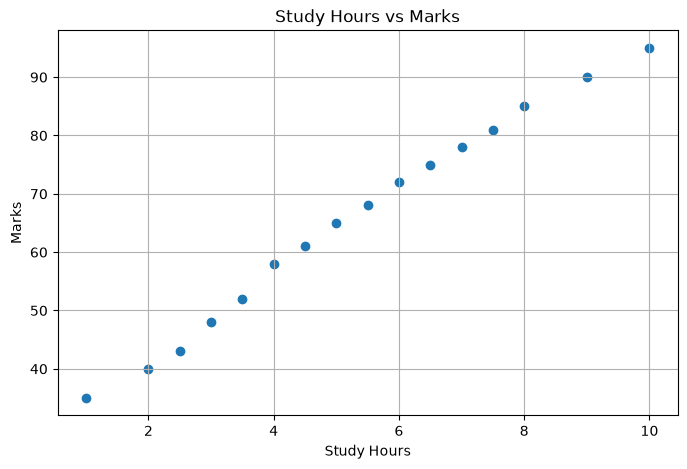

In [3]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Study_Hours"],
    df["Marks"]
)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")

plt.grid(True)
plt.show()

In [7]:
# Prepare Data
X = df[["Study_Hours"]]
y = df["Marks"]

# Split Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Linear Regression Model
reg_model = LinearRegression()

reg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7.03]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Study_Hours']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,28.17
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [8]:
# Make Predictions
y_pred = reg_model.predict(X_test)

results = pd.DataFrame({
    "Actual Marks": y_test,
    "Predicted Marks": y_pred.round(2)
})

results

,Actual Marks,Predicted Marks
0,35,35.20
1,40,42.23
5,58,56.28
14,90,91.42


# Evaluate Regression Model

We will use:

- MAE
- MSE
- R²

In [9]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("Regression Evaluation")
print("---------------------")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Regression Evaluation
---------------------
MAE: 1.39
MSE: 2.49
R² Score: 0.99


## Summary of Model Performance:

    The Linear Regression model predicts student marks from study hours. 
    The model achieved an MAE of {mae:.2f} marks and an R² score of {r2:.2f}.
    A lower MAE indicates smaller prediction errors, while an R² value closer 
    to 1 indicates that the model explains the relationship between study hours 
    and marks well."


# Pass/Fail Classifier

In [10]:
# Create Pass/Fail Target
df["Pass_Fail"] = (df["Marks"] >= 50).astype(int)
df

# Prepare Classification Data
X = df[["Study_Hours"]]
y = df["Pass_Fail"]

In [11]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Train Logistic Regression Classifier
clf_model = LogisticRegression()

clf_model.fit(X_train, y_train)

# Make Predictions
y_pred_class = clf_model.predict(X_test)

results_classification = pd.DataFrame({
    "Study Hours": X_test["Study_Hours"],
    "Actual": y_test,
    "Predicted": y_pred_class
})

results_classification.sort_values("Study Hours")

,Study Hours,Actual,Predicted
2,2.5,0,0
8,5.5,1,1
11,7.0,1,1
14,9.0,1,1


In [12]:
# Evaluate Classification Model
accuracy = accuracy_score(y_test, y_pred_class)

cm = confusion_matrix(y_test, y_pred_class)

print("Classification Evaluation")
print("-------------------------")
print(f"Accuracy: {accuracy:.2f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_class,
    target_names=["Fail", "Pass"],
    zero_division=0
))

Classification Evaluation
-------------------------
Accuracy: 1.00

Confusion Matrix:
[[1 0]
 [0 3]]

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      1.00      1.00         1
        Pass       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



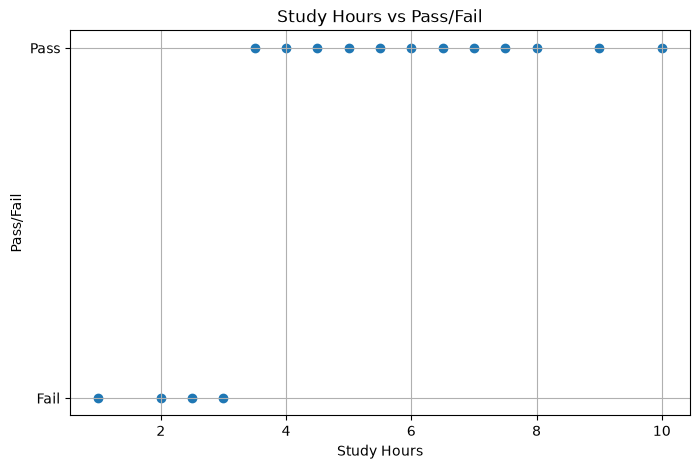

In [13]:
# Visualize Classification Results
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Study_Hours"],
    df["Pass_Fail"]
)

plt.xlabel("Study Hours")
plt.ylabel("Pass/Fail")
plt.title("Study Hours vs Pass/Fail")

plt.yticks(
    [0, 1],
    ["Fail", "Pass"]
)

plt.grid(True)
plt.show()

In [15]:
# Predict marks
new_student = pd.DataFrame({
    "Study_Hours": [6]
})

predicted_marks = reg_model.predict(new_student)

print(
    f"Predicted marks for 6 study hours: "
    f"{predicted_marks[0]:.2f}"
)

Predicted marks for 6 study hours: 70.34


In [16]:
# Predict Pass/Fail
predicted_class = clf_model.predict(new_student)

if predicted_class[0] == 1:
    result = "Pass"
else:
    result = "Fail"

print(f"Pass/Fail prediction: {result}")

Pass/Fail prediction: Pass


#  **FINAL PROJECT SUMMARY**

    The Linear Regression model predicts marks from study hours. 
    It achieved an MAE of {mae:.2f} and an R² score of {r2:.2f}. 
    This shows how accurately study hours can be used to estimate student marks.

    The Logistic Regression model predicts whether a student will pass or fail. 
    It achieved an accuracy of {accuracy:.2f}. 
    The confusion matrix and classification report provide additional information
    about correct and incorrect Pass/Fail predictions."
